# ADHD classification from EEG: EEGNet + feature MLP ensemble

## Ready-to-run Google Colab notebook

**Research question:** Can ADHD status be predicted from 19-channel EEG recorded during a visual-attention task?

This notebook compares and combines two complementary neural networks:

1. **EEGNet-style CNN** on raw ordered EEG windows. It preserves sample order inside each window and learns temporal and cross-channel patterns.
2. **Feature MLP** on time-domain and frequency-domain features. It is smaller and more interpretable.
3. **Fixed 50/50 ensemble** of their participant-level probabilities.

The evaluation is participant-safe: participants are split before windows, so the same child never appears in both training and validation data. The primary estimate is **out-of-fold participant-level performance from stratified 5-fold cross-validation**.

### Important interpretation

- This is an exploratory machine-learning project, not a clinical diagnostic system.
- The notebook assumes a sampling rate of **128 Hz**, as stated in the dataset description used for the project. Verify this against the original source before reporting time in seconds.
- The CSV must preserve chronological row order within each participant.

## How to run

1. In Colab, choose **Runtime → Change runtime type → T4 GPU** (or another GPU).
2. Put `adhdata.csv` in Google Drive, paste a sharing link or mounted Drive path in the configuration cell.
3. Choose **Runtime → Run all**.
4. The final cell creates a ZIP archive containing metrics, plots, predictions, and model checkpoints.

The default configuration is designed for a Colab GPU. Set `QUICK_MODE = True` for a faster first run. Full 5-fold evaluation can take tens of minutes depending on the allocated GPU.

In [ ]:
# Install small missing dependencies only when necessary.
import importlib.util
import subprocess
import sys

IN_COLAB = importlib.util.find_spec("google.colab") is not None
for package in ["gdown", "joblib"]:
    if importlib.util.find_spec(package) is None:
        if IN_COLAB:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        else:
            print(f"Optional package {package!r} is unavailable outside Colab.")

print("Dependency check completed.")


Dependency check completed.


In [ ]:
# Imports and reproducibility
import copy
import gc
import json
import math
import os
import random
import shutil
import time
import warnings
from pathlib import Path

try:
    import gdown
except ImportError:
    gdown = None

try:
    import joblib
except ImportError:
    joblib = None
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: No GPU detected. The notebook will run, but EEGNet training will be slower.")

PyTorch version: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


## 1. Configuration

The full mode uses 512-sample windows with 50% overlap and retains up to 80 evenly spaced windows per participant. This keeps the complete task trajectory represented while controlling runtime and unequal recording lengths.

`SMOKE_TEST` is automatically enabled only when the environment variable `EEG_SMOKE_TEST=1` is set. It is used to verify that the notebook runs from start to finish quickly.

In [ ]:
# --------------------------- USER CONFIGURATION ---------------------------

# Paste a public Google Drive sharing link here, or leave blank and use a path.
GOOGLE_DRIVE_LINK =  "https://drive.google.com/file/d/1UltincUwi1V_JXtxRUpSTnBJjzaqdHMQ/view?usp=sharing"


# Examples:
# DATA_PATH_OVERRIDE = "/content/drive/MyDrive/eeg_project/adhdata.csv"
# DATA_PATH_OVERRIDE = "/content/adhdata.csv"
DATA_PATH_OVERRIDE = ""

# Runtime profile
QUICK_MODE = False          # True: 3 folds, fewer windows, fewer epochs
TRAIN_FINAL_MODELS = True   # Fit deployable models on all participants after CV

# Output handling
SAVE_OUTPUTS_TO_DRIVE = False
DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/eegnet_project_outputs"
DOWNLOAD_ZIP_AT_END = False

# Signal/window settings
SAMPLING_RATE_HZ = 128
WINDOW_SIZE = 512           # 4 seconds only if 128 Hz is verified
WINDOW_STRIDE = 256         # 50% overlap
MAX_WINDOWS_PER_SUBJECT = 80
USE_FREQUENCY_FEATURES = True

# Cross-validation and training
N_SPLITS = 5
INNER_VALIDATION_FRACTION = 0.15
BATCH_SIZE = 64
EEGNET_MAX_EPOCHS = 40
MLP_MAX_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 8
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0             # 0 is safest in Colab notebooks
ENSEMBLE_EEGNET_WEIGHT = 0.5  # fixed in advance to avoid optimistic tuning

# Data augmentation for raw EEG windows
USE_RAW_AUGMENTATION = True
NOISE_STD = 0.01
AMPLITUDE_SCALE_STD = 0.05

# Automatic smoke-test mode for notebook validation.
SMOKE_TEST = os.getenv("EEG_SMOKE_TEST", "0") == "1"
if SMOKE_TEST:
    QUICK_MODE = True
    TRAIN_FINAL_MODELS = False
    N_SPLITS = 2
    MAX_WINDOWS_PER_SUBJECT = 4
    EEGNET_MAX_EPOCHS = 2
    MLP_MAX_EPOCHS = 2
    EARLY_STOPPING_PATIENCE = 1
    USE_RAW_AUGMENTATION = False
elif QUICK_MODE:
    N_SPLITS = 3
    MAX_WINDOWS_PER_SUBJECT = 40
    EEGNET_MAX_EPOCHS = 20
    MLP_MAX_EPOCHS = 25
    EARLY_STOPPING_PATIENCE = 5

print({
    "quick_mode": QUICK_MODE,
    "smoke_test": SMOKE_TEST,
    "folds": N_SPLITS,
    "window_size": WINDOW_SIZE,
    "stride": WINDOW_STRIDE,
    "max_windows_per_subject": MAX_WINDOWS_PER_SUBJECT,
    "device": str(DEVICE),
})

{'quick_mode': False, 'smoke_test': False, 'folds': 5, 'window_size': 512, 'stride': 256, 'max_windows_per_subject': 80, 'device': 'cuda'}


In [ ]:
# Output directory
if SAVE_OUTPUTS_TO_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as exc:
        raise RuntimeError("Could not mount Google Drive.") from exc
    OUTPUT_DIR = Path(DRIVE_OUTPUT_DIR)
else:
    OUTPUT_DIR = Path("/content/eegnet_project_outputs") if Path("/content").exists() else Path("/mnt/data/eegnet_project_outputs")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Outputs will be written to:", OUTPUT_DIR)

Outputs will be written to: /content/eegnet_project_outputs


## 2. Load and validate the CSV

The loader tries, in order:

1. environment variable `EEG_DATA_PATH`;
2. `DATA_PATH_OVERRIDE`;
3. common local paths;
4. Google Drive link download;
5. manual Colab upload.

In [ ]:
def resolve_data_path():
    candidates = [
        os.getenv("EEG_DATA_PATH", ""),
        DATA_PATH_OVERRIDE,
        "/content/adhdata.csv",
        "/mnt/data/adhdata.csv",
    ]
    for candidate in candidates:
        if candidate and Path(candidate).exists():
            return Path(candidate)

    if GOOGLE_DRIVE_LINK.strip():
        if gdown is None:
            raise ImportError("gdown is required for Google Drive link downloads.")
        target = Path("/content/adhdata.csv") if Path("/content").exists() else Path("/mnt/data/adhdata.csv")
        print("Downloading dataset from Google Drive...")
        gdown.download(GOOGLE_DRIVE_LINK.strip(), str(target), fuzzy=True, quiet=False)
        if target.exists():
            return target

    try:
        from google.colab import files
        print("No file path was found. Upload adhdata.csv now.")
        uploaded = files.upload()
        if not uploaded:
            raise FileNotFoundError("No file was uploaded.")
        uploaded_name = next(iter(uploaded))
        return Path(uploaded_name)
    except ImportError as exc:
        raise FileNotFoundError(
            "Could not locate adhdata.csv. Set DATA_PATH_OVERRIDE or EEG_DATA_PATH."
        ) from exc

DATA_PATH = resolve_data_path()
print("Using dataset:", DATA_PATH)
print(f"File size: {DATA_PATH.stat().st_size / 1024**2:.1f} MB")

Downloading...
From (original): https://drive.google.com/uc?id=1UltincUwi1V_JXtxRUpSTnBJjzaqdHMQ
From (redirected): https://drive.google.com/uc?id=1UltincUwi1V_JXtxRUpSTnBJjzaqdHMQ&confirm=t&uuid=f0fda2ae-2587-4059-b662-c699a1b81b9e
To: /content/adhdata.csv
100%|██████████| 267M/267M [00:05<00:00, 50.6MB/s]

Using dataset: /content/adhdata.csv
File size: 254.9 MB


In [ ]:
EEG_CHANNELS = [
    "Fp1", "Fp2", "F3", "F4", "C3", "C4", "P3", "P4", "O1", "O2",
    "F7", "F8", "T7", "T8", "P7", "P8", "Fz", "Cz", "Pz"
]
EXPECTED_COLUMNS = EEG_CHANNELS + ["Class", "ID"]
LABEL_MAPPING = {"Control": 0, "ADHD": 1}

column_types = {channel: "float32" for channel in EEG_CHANNELS}
column_types.update({"Class": "category", "ID": "category"})

data = pd.read_csv(DATA_PATH, dtype=column_types)
missing_columns = [column for column in EXPECTED_COLUMNS if column not in data.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

data = data[EXPECTED_COLUMNS].copy()
data["Class"] = data["Class"].astype(str).str.strip()
data["ID"] = data["ID"].astype(str).str.strip()

unknown_labels = sorted(set(data["Class"]) - set(LABEL_MAPPING))
if unknown_labels:
    raise ValueError(f"Unexpected class labels: {unknown_labels}")

if data[EEG_CHANNELS].isna().any().any():
    raise ValueError("The EEG columns contain missing values. Handle them before training.")
if not np.isfinite(data[EEG_CHANNELS].to_numpy()).all():
    raise ValueError("The EEG columns contain infinite or invalid values.")

classes_per_subject = data.groupby("ID")["Class"].nunique()
if (classes_per_subject > 1).any():
    raise ValueError("At least one participant has more than one class label.")

subject_table = (
    data.groupby("ID", sort=False)
    .agg(Class=("Class", "first"), number_of_rows=("Class", "size"))
    .reset_index()
)
subject_table["label"] = subject_table["Class"].map(LABEL_MAPPING).astype(int)

print(f"Rows: {len(data):,}")
print(f"Participants: {len(subject_table)}")
print(subject_table["Class"].value_counts())
display(subject_table.head())

subject_table.to_csv(OUTPUT_DIR / "participant_overview.csv", index=False)

Rows: 2,166,383
Participants: 121
Class
ADHD       61
Control    60
Name: count, dtype: int64


,ID,Class,number_of_rows,label
0,v10p,ADHD,14304,1
1,v12p,ADHD,17604,1
2,v14p,ADHD,17562,1
3,v15p,ADHD,43252,1
4,v173,ADHD,24241,1


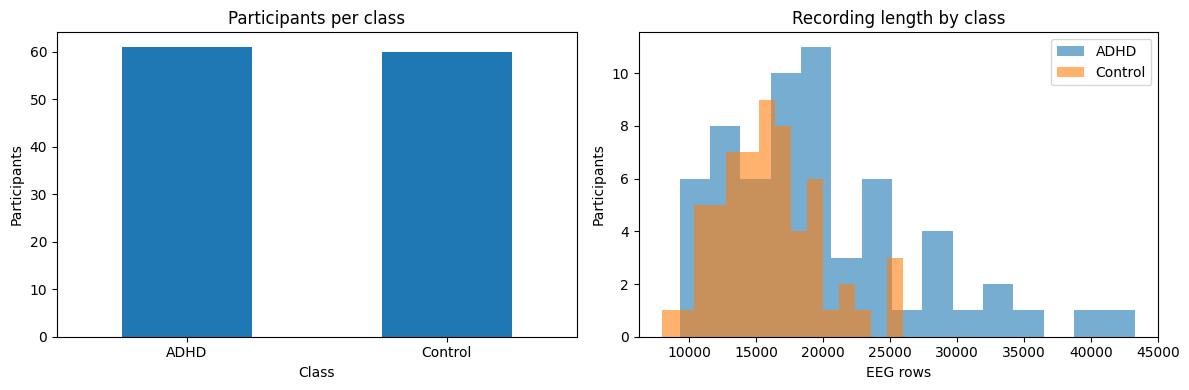

In [ ]:
# Basic participant-level visualizations
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
subject_table["Class"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Participants per class")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Participants")
axes[0].tick_params(axis="x", rotation=0)

for class_name, group in subject_table.groupby("Class"):
    axes[1].hist(group["number_of_rows"], bins=15, alpha=0.6, label=class_name)
axes[1].set_title("Recording length by class")
axes[1].set_xlabel("EEG rows")
axes[1].set_ylabel("Participants")
axes[1].legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "dataset_overview.png", dpi=160, bbox_inches="tight")
plt.show()

## 3. Window extraction and feature engineering

For each participant, windows are created in chronological order. When a recording contains more than the configured maximum, windows are selected evenly from the beginning to the end.

The raw EEGNet input has shape:

\[
(1, 19, 512)
\]

The MLP receives:

- mean, standard deviation, minimum, maximum, median, and RMS for each channel;
- log band power for delta, theta, alpha, beta, and low-gamma bands;
- normalized window position from 0 (beginning) to 1 (end).

In [ ]:
FREQUENCY_BANDS = {
    "delta": (1.0, 4.0),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta": (13.0, 30.0),
    "low_gamma": (30.0, 40.0),
}
TIME_STATISTICS = ["mean", "std", "min", "max", "median", "rms"]


def select_window_starts(n_rows, window_size, stride, max_windows):
    if n_rows < window_size:
        return np.empty(0, dtype=np.int64)
    starts = np.arange(0, n_rows - window_size + 1, stride, dtype=np.int64)
    if max_windows is not None and len(starts) > max_windows:
        chosen = np.linspace(0, len(starts) - 1, num=max_windows, dtype=np.int64)
        starts = starts[np.unique(chosen)]
    return starts


def extract_feature_matrix(windows, relative_position):
    # windows: [n_windows, n_channels, n_samples]
    parts = [
        windows.mean(axis=2),
        windows.std(axis=2),
        windows.min(axis=2),
        windows.max(axis=2),
        np.median(windows, axis=2),
        np.sqrt(np.mean(np.square(windows), axis=2)),
    ]

    if USE_FREQUENCY_FEATURES:
        fft_values = np.fft.rfft(windows, axis=2)
        power = (np.abs(fft_values) ** 2) / windows.shape[2]
        frequencies = np.fft.rfftfreq(windows.shape[2], d=1.0 / SAMPLING_RATE_HZ)
        for low, high in FREQUENCY_BANDS.values():
            mask = (frequencies >= low) & (frequencies < high)
            if not mask.any():
                band_power = np.zeros(windows.shape[:2], dtype=np.float32)
            else:
                band_power = np.log1p(power[:, :, mask].mean(axis=2))
            parts.append(band_power)

    parts.append(relative_position[:, None])
    return np.concatenate(parts, axis=1).astype(np.float32)


def make_feature_names():
    names = []
    for statistic in TIME_STATISTICS:
        names.extend([f"{channel}_{statistic}" for channel in EEG_CHANNELS])
    if USE_FREQUENCY_FEATURES:
        for band_name in FREQUENCY_BANDS:
            names.extend([f"{channel}_{band_name}_logpower" for channel in EEG_CHANNELS])
    names.append("relative_position")
    return names

FEATURE_NAMES = make_feature_names()
print("Number of MLP features:", len(FEATURE_NAMES))

Number of MLP features: 210


In [ ]:
raw_window_chunks = []
feature_chunks = []
metadata_chunks = []

start_time = time.time()
for subject_number, (subject_id, subject_data) in enumerate(data.groupby("ID", sort=False), start=1):
    class_name = subject_data["Class"].iloc[0]
    label = LABEL_MAPPING[class_name]
    values = subject_data[EEG_CHANNELS].to_numpy(dtype=np.float32, copy=False)

    starts = select_window_starts(
        len(values), WINDOW_SIZE, WINDOW_STRIDE, MAX_WINDOWS_PER_SUBJECT
    )
    if len(starts) == 0:
        print(f"Skipping {subject_id}: fewer than {WINDOW_SIZE} rows.")
        continue

    # [n_windows, channels, samples]
    windows = np.stack([values[start:start + WINDOW_SIZE].T for start in starts]).astype(np.float32)
    denominator = max(len(values) - WINDOW_SIZE, 1)
    relative_position = (starts / denominator).astype(np.float32)
    features = extract_feature_matrix(windows, relative_position)

    raw_window_chunks.append(windows)
    feature_chunks.append(features)
    metadata_chunks.append(pd.DataFrame({
        "ID": subject_id,
        "Class": class_name,
        "label": label,
        "window_start": starts,
        "window_number": np.arange(len(starts), dtype=int),
        "relative_position": relative_position,
    }))

    if subject_number % 20 == 0:
        print(f"Processed {subject_number}/{len(subject_table)} participants")

raw_windows = np.concatenate(raw_window_chunks, axis=0)
feature_matrix = np.concatenate(feature_chunks, axis=0)
window_metadata = pd.concat(metadata_chunks, ignore_index=True)

del raw_window_chunks, feature_chunks, metadata_chunks, data
gc.collect()

assert len(raw_windows) == len(feature_matrix) == len(window_metadata)
assert raw_windows.shape[1:] == (len(EEG_CHANNELS), WINDOW_SIZE)
assert feature_matrix.shape[1] == len(FEATURE_NAMES)

print(f"Windows: {len(window_metadata):,}")
print("Raw window array:", raw_windows.shape, raw_windows.dtype)
print("Feature matrix:", feature_matrix.shape, feature_matrix.dtype)
print(f"Extraction time: {(time.time() - start_time) / 60:.1f} minutes")
print(f"Raw-window memory: {raw_windows.nbytes / 1024**2:.1f} MB")

display(window_metadata.groupby(["Class", "ID"]).size().groupby(level=0).describe())
window_metadata.to_csv(OUTPUT_DIR / "window_metadata.csv", index=False)
with open(OUTPUT_DIR / "feature_names.json", "w") as file:
    json.dump(FEATURE_NAMES, file, indent=2)

Processed 20/121 participants
Processed 40/121 participants
Processed 60/121 participants
Processed 80/121 participants
Processed 100/121 participants
Processed 120/121 participants
Windows: 7,625
Raw window array: (7625, 19, 512) float32
Feature matrix: (7625, 210) float32
Extraction time: 0.0 minutes
Raw-window memory: 283.0 MB


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
ADHD,61.0,66.245902,14.579273,35.0,54.0,70.0,80.0,80.0
Control,60.0,59.733333,12.531813,30.0,51.0,59.5,68.0,80.0


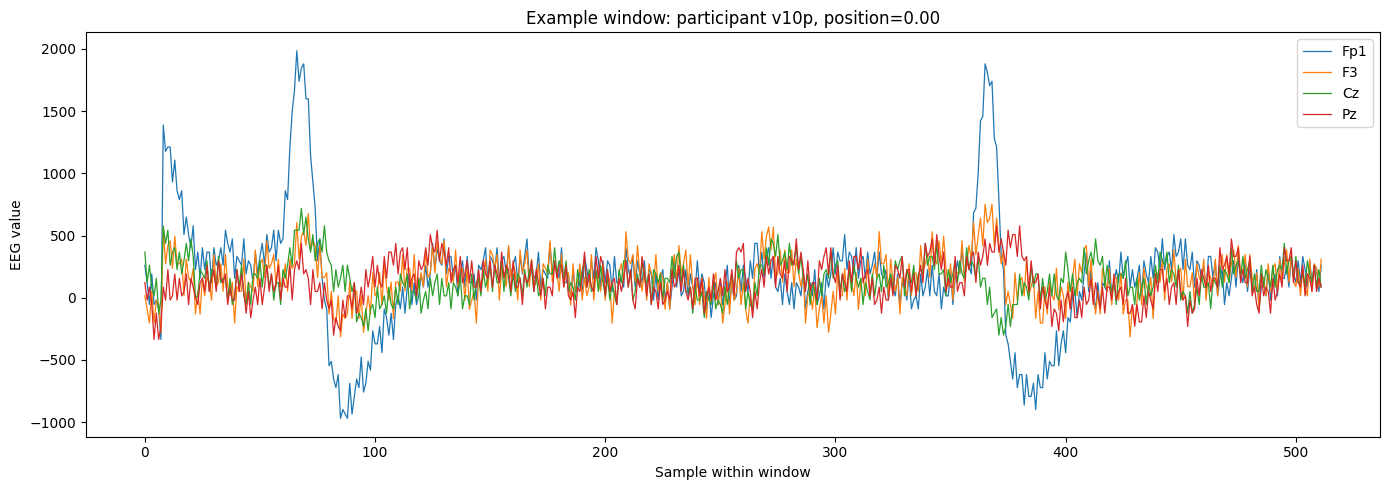

In [ ]:
# Example raw window and its position
example_index = 0
plt.figure(figsize=(14, 5))
for channel in ["Fp1", "F3", "Cz", "Pz"]:
    channel_index = EEG_CHANNELS.index(channel)
    plt.plot(raw_windows[example_index, channel_index], label=channel, linewidth=0.9)
plt.title(
    f"Example window: participant {window_metadata.loc[example_index, 'ID']}, "
    f"position={window_metadata.loc[example_index, 'relative_position']:.2f}"
)
plt.xlabel("Sample within window")
plt.ylabel("EEG value")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "example_raw_window.png", dpi=160, bbox_inches="tight")
plt.show()

## 4. PyTorch datasets and models

Training batches use participant-equal sample weights: windows from a participant sum to approximately the same total weight as windows from any other participant. This prevents longer recordings from dominating the loss.

In [ ]:
def participant_equal_weights(metadata, indices):
    ids = metadata.iloc[indices]["ID"].to_numpy()
    unique_ids, counts = np.unique(ids, return_counts=True)
    count_map = dict(zip(unique_ids, counts))
    weights = np.array([1.0 / count_map[subject_id] for subject_id in ids], dtype=np.float32)
    return weights / weights.mean()


def compute_channel_stats(windows, indices, chunk_size=256):
    total_sum = np.zeros(windows.shape[1], dtype=np.float64)
    total_sumsq = np.zeros(windows.shape[1], dtype=np.float64)
    total_count = 0
    for start in range(0, len(indices), chunk_size):
        chunk = windows[indices[start:start + chunk_size]].astype(np.float64)
        total_sum += chunk.sum(axis=(0, 2))
        total_sumsq += np.square(chunk).sum(axis=(0, 2))
        total_count += chunk.shape[0] * chunk.shape[2]
    mean = total_sum / total_count
    variance = np.maximum(total_sumsq / total_count - np.square(mean), 1e-8)
    return mean.astype(np.float32), np.sqrt(variance).astype(np.float32)


class RawWindowDataset(Dataset):
    def __init__(self, windows, metadata, indices, channel_mean, channel_std, augment=False):
        self.windows = windows
        self.indices = np.asarray(indices, dtype=np.int64)
        self.labels = metadata.iloc[self.indices]["label"].to_numpy(np.float32)
        self.positions = metadata.iloc[self.indices]["relative_position"].to_numpy(np.float32)
        self.weights = participant_equal_weights(metadata, self.indices)
        self.mean = channel_mean[:, None]
        self.std = channel_std[:, None]
        self.augment = augment

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, item):
        window = (self.windows[self.indices[item]] - self.mean) / self.std
        window = window.astype(np.float32, copy=True)
        if self.augment:
            scale = np.float32(np.random.normal(1.0, AMPLITUDE_SCALE_STD))
            noise = np.random.normal(0.0, NOISE_STD, size=window.shape).astype(np.float32)
            window = window * scale + noise
        x = torch.from_numpy(window[None, :, :])
        position = torch.tensor([self.positions[item]], dtype=torch.float32)
        label = torch.tensor(self.labels[item], dtype=torch.float32)
        weight = torch.tensor(self.weights[item], dtype=torch.float32)
        return x, position, label, weight


class FeatureDataset(Dataset):
    def __init__(self, scaled_features, metadata, indices):
        self.x = np.asarray(scaled_features, dtype=np.float32)
        self.indices = np.asarray(indices, dtype=np.int64)
        self.labels = metadata.iloc[self.indices]["label"].to_numpy(np.float32)
        self.positions = metadata.iloc[self.indices]["relative_position"].to_numpy(np.float32)
        self.weights = participant_equal_weights(metadata, self.indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, item):
        x = torch.from_numpy(self.x[item])
        position = torch.tensor([self.positions[item]], dtype=torch.float32)
        label = torch.tensor(self.labels[item], dtype=torch.float32)
        weight = torch.tensor(self.weights[item], dtype=torch.float32)
        return x, position, label, weight


def make_loader(dataset, shuffle):
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        drop_last=False,
    )

In [ ]:
class EEGNet(nn.Module):
    """Compact EEGNet-style CNN with normalized recording position."""

    def __init__(self, n_channels=19, f1=8, depth_multiplier=2, f2=16, dropout=0.5):
        super().__init__()
        temporal_kernel = 63
        separable_kernel = 15

        self.temporal = nn.Conv2d(
            1, f1, kernel_size=(1, temporal_kernel),
            padding=(0, temporal_kernel // 2), bias=False
        )
        self.bn1 = nn.BatchNorm2d(f1)

        self.spatial = nn.Conv2d(
            f1, f1 * depth_multiplier,
            kernel_size=(n_channels, 1),
            groups=f1,
            bias=False,
        )
        self.bn2 = nn.BatchNorm2d(f1 * depth_multiplier)
        self.pool1 = nn.AvgPool2d(kernel_size=(1, 4))
        self.dropout1 = nn.Dropout(dropout)

        self.depthwise_temporal = nn.Conv2d(
            f1 * depth_multiplier,
            f1 * depth_multiplier,
            kernel_size=(1, separable_kernel),
            padding=(0, separable_kernel // 2),
            groups=f1 * depth_multiplier,
            bias=False,
        )
        self.pointwise = nn.Conv2d(f1 * depth_multiplier, f2, kernel_size=(1, 1), bias=False)
        self.bn3 = nn.BatchNorm2d(f2)
        self.pool2 = nn.AvgPool2d(kernel_size=(1, 8))
        self.dropout2 = nn.Dropout(dropout)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(f2 + 1, 1)

    def forward(self, x, position):
        x = self.bn1(self.temporal(x))
        x = F.elu(self.bn2(self.spatial(x)))
        x = self.dropout1(self.pool1(x))
        x = self.depthwise_temporal(x)
        x = F.elu(self.bn3(self.pointwise(x)))
        x = self.dropout2(self.pool2(x))
        x = self.global_pool(x).flatten(1)
        x = torch.cat([x, position], dim=1)
        return self.classifier(x).squeeze(1)


class FeatureMLP(nn.Module):
    def __init__(self, input_dim, dropout=0.4):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 32),
            nn.LayerNorm(32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x, position=None):
        return self.network(x).squeeze(1)

print(EEGNet())
print(FeatureMLP(len(FEATURE_NAMES)))

EEGNet(
  (temporal): Conv2d(1, 8, kernel_size=(1, 63), stride=(1, 1), padding=(0, 31), bias=False)
  (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (spatial): Conv2d(8, 16, kernel_size=(19, 1), stride=(1, 1), groups=8, bias=False)
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
  (dropout1): Dropout(p=0.5, inplace=False)
  (depthwise_temporal): Conv2d(16, 16, kernel_size=(1, 15), stride=(1, 1), padding=(0, 7), groups=16, bias=False)
  (pointwise): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
  (dropout2): Dropout(p=0.5, inplace=False)
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Linear(in_features=17, out_features=1, bias=True)
)
FeatureMLP(
 

## 5. Training, prediction, and participant aggregation

The outer fold is used only for evaluation. Inside each outer-training set, a small participant-level split determines the stopping epoch. The model is then reinitialized and retrained on all outer-training participants for that many epochs before evaluating the untouched outer fold.

In [ ]:
def weighted_bce_loss(logits, labels, weights):
    losses = F.binary_cross_entropy_with_logits(logits, labels, reduction="none")
    return (losses * weights).sum() / weights.sum().clamp_min(1e-8)


def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    total_weight = 0.0

    for x, position, labels, weights in loader:
        x = x.to(DEVICE, non_blocking=True)
        position = position.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        weights = weights.to(DEVICE, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        logits = model(x, position)
        loss = weighted_bce_loss(logits, labels, weights)

        if training:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

        batch_weight = float(weights.sum().detach().cpu())
        total_loss += float(loss.detach().cpu()) * batch_weight
        total_weight += batch_weight

    return total_loss / max(total_weight, 1e-8)


def train_with_early_stopping(model, train_loader, validation_loader, max_epochs, seed):
    seed_everything(seed)
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2
    )

    best_state = None
    best_epoch = 1
    best_validation_loss = float("inf")
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        train_loss = run_epoch(model, train_loader, optimizer)
        with torch.no_grad():
            validation_loss = run_epoch(model, validation_loader)
        scheduler.step(validation_loss)
        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "validation_loss": validation_loss,
            "learning_rate": optimizer.param_groups[0]["lr"],
        })

        if validation_loss < best_validation_loss - 1e-4:
            best_validation_loss = validation_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"epoch {epoch:03d} | train {train_loss:.4f} | "
                f"validation {validation_loss:.4f}"
            )
        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            break

    model.load_state_dict(best_state)
    return model, best_epoch, pd.DataFrame(history)


def train_fixed_epochs(model, train_loader, epochs, seed):
    seed_everything(seed)
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=max(epochs, 1)
    )
    history = []
    for epoch in range(1, epochs + 1):
        train_loss = run_epoch(model, train_loader, optimizer)
        scheduler.step()
        history.append({"epoch": epoch, "train_loss": train_loss})
    return model, pd.DataFrame(history)


@torch.no_grad()
def predict_probabilities(model, loader):
    model.eval()
    probabilities = []
    labels = []
    for x, position, y, _weights in loader:
        logits = model(
            x.to(DEVICE, non_blocking=True),
            position.to(DEVICE, non_blocking=True),
        )
        probabilities.append(torch.sigmoid(logits).cpu().numpy())
        labels.append(y.numpy())
    return np.concatenate(probabilities), np.concatenate(labels).astype(int)


def classification_metrics(y_true, probability, threshold=0.5):
    prediction = (np.asarray(probability) >= threshold).astype(int)
    result = {
        "accuracy": accuracy_score(y_true, prediction),
        "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "f1": f1_score(y_true, prediction, zero_division=0),
    }
    result["roc_auc"] = roc_auc_score(y_true, probability) if len(np.unique(y_true)) == 2 else np.nan
    return result


def aggregate_participant_predictions(metadata_subset, probabilities_by_model):
    frame = metadata_subset[["ID", "Class", "label", "relative_position"]].copy()
    for model_name, probabilities in probabilities_by_model.items():
        frame[f"{model_name}_window_probability"] = probabilities

    aggregation = {"Class": "first", "label": "first", "relative_position": "count"}
    for model_name in probabilities_by_model:
        aggregation[f"{model_name}_window_probability"] = "mean"

    participant = frame.groupby("ID", sort=False).agg(aggregation).reset_index()
    participant = participant.rename(columns={"relative_position": "number_of_windows"})
    for model_name in probabilities_by_model:
        participant = participant.rename(columns={
            f"{model_name}_window_probability": f"{model_name}_probability"
        })
    return participant, frame

## 6. Stratified participant-level cross-validation

The ensemble weight is fixed at 0.5 before evaluation. It is not optimized on the out-of-fold predictions.

In [ ]:
participant_labels = (
    window_metadata[["ID", "Class", "label"]]
    .drop_duplicates("ID")
    .reset_index(drop=True)
)

if participant_labels["label"].value_counts().min() < N_SPLITS:
    raise ValueError("N_SPLITS is larger than the number of participants in the smaller class.")

outer_cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

fold_metric_rows = []
oof_participant_frames = []
oof_window_frames = []
epoch_rows = []
all_history_rows = []

cv_start_time = time.time()
for fold, (outer_train_subject_rows, outer_validation_subject_rows) in enumerate(
    outer_cv.split(participant_labels["ID"], participant_labels["label"]), start=1
):
    print("\n" + "=" * 80)
    print(f"OUTER FOLD {fold}/{N_SPLITS}")
    print("=" * 80)

    outer_train_subjects = participant_labels.iloc[outer_train_subject_rows].copy()
    outer_validation_subjects = participant_labels.iloc[outer_validation_subject_rows].copy()
    outer_train_ids = set(outer_train_subjects["ID"])
    outer_validation_ids = set(outer_validation_subjects["ID"])
    assert outer_train_ids.isdisjoint(outer_validation_ids)

    outer_train_indices = np.flatnonzero(window_metadata["ID"].isin(outer_train_ids).to_numpy())
    outer_validation_indices = np.flatnonzero(window_metadata["ID"].isin(outer_validation_ids).to_numpy())

    # Inner participant split for epoch selection.
    inner_train_subjects, inner_validation_subjects = train_test_split(
        outer_train_subjects,
        test_size=INNER_VALIDATION_FRACTION,
        random_state=SEED + fold,
        stratify=outer_train_subjects["label"],
    )
    inner_train_ids = set(inner_train_subjects["ID"])
    inner_validation_ids = set(inner_validation_subjects["ID"])
    inner_train_indices = np.flatnonzero(window_metadata["ID"].isin(inner_train_ids).to_numpy())
    inner_validation_indices = np.flatnonzero(window_metadata["ID"].isin(inner_validation_ids).to_numpy())

    print(
        f"Participants: outer train={len(outer_train_ids)}, "
        f"outer validation={len(outer_validation_ids)}, "
        f"inner validation={len(inner_validation_ids)}"
    )

    # -------------------- EEGNET EPOCH SELECTION --------------------
    inner_channel_mean, inner_channel_std = compute_channel_stats(raw_windows, inner_train_indices)
    eeg_inner_train = make_loader(RawWindowDataset(
        raw_windows, window_metadata, inner_train_indices,
        inner_channel_mean, inner_channel_std,
        augment=USE_RAW_AUGMENTATION,
    ), shuffle=True)
    eeg_inner_validation = make_loader(RawWindowDataset(
        raw_windows, window_metadata, inner_validation_indices,
        inner_channel_mean, inner_channel_std,
        augment=False,
    ), shuffle=False)

    print("Selecting EEGNet epoch...")
    eeg_selection_model, eeg_best_epoch, eeg_history = train_with_early_stopping(
        EEGNet(n_channels=len(EEG_CHANNELS)),
        eeg_inner_train,
        eeg_inner_validation,
        EEGNET_MAX_EPOCHS,
        seed=SEED + fold * 100,
    )
    eeg_history["fold"] = fold
    eeg_history["model"] = "eegnet_epoch_selection"
    all_history_rows.append(eeg_history)
    del eeg_selection_model, eeg_inner_train, eeg_inner_validation
    torch.cuda.empty_cache()

    # -------------------- MLP EPOCH SELECTION --------------------
    inner_scaler = StandardScaler()
    inner_train_features = inner_scaler.fit_transform(feature_matrix[inner_train_indices]).astype(np.float32)
    inner_validation_features = inner_scaler.transform(feature_matrix[inner_validation_indices]).astype(np.float32)
    mlp_inner_train = make_loader(
        FeatureDataset(inner_train_features, window_metadata, inner_train_indices), shuffle=True
    )
    mlp_inner_validation = make_loader(
        FeatureDataset(inner_validation_features, window_metadata, inner_validation_indices), shuffle=False
    )

    print("Selecting feature-MLP epoch...")
    mlp_selection_model, mlp_best_epoch, mlp_history = train_with_early_stopping(
        FeatureMLP(len(FEATURE_NAMES)),
        mlp_inner_train,
        mlp_inner_validation,
        MLP_MAX_EPOCHS,
        seed=SEED + fold * 100 + 1,
    )
    mlp_history["fold"] = fold
    mlp_history["model"] = "mlp_epoch_selection"
    all_history_rows.append(mlp_history)
    del mlp_selection_model, mlp_inner_train, mlp_inner_validation
    torch.cuda.empty_cache()

    epoch_rows.append({
        "fold": fold,
        "eegnet_epochs": eeg_best_epoch,
        "mlp_epochs": mlp_best_epoch,
    })
    print(f"Selected epochs: EEGNet={eeg_best_epoch}, MLP={mlp_best_epoch}")

    # -------------------- RETRAIN EEGNET ON ALL OUTER-TRAIN SUBJECTS --------------------
    outer_channel_mean, outer_channel_std = compute_channel_stats(raw_windows, outer_train_indices)
    eeg_outer_train = make_loader(RawWindowDataset(
        raw_windows, window_metadata, outer_train_indices,
        outer_channel_mean, outer_channel_std,
        augment=USE_RAW_AUGMENTATION,
    ), shuffle=True)
    eeg_outer_validation = make_loader(RawWindowDataset(
        raw_windows, window_metadata, outer_validation_indices,
        outer_channel_mean, outer_channel_std,
        augment=False,
    ), shuffle=False)

    eeg_model, eeg_retrain_history = train_fixed_epochs(
        EEGNet(n_channels=len(EEG_CHANNELS)), eeg_outer_train,
        epochs=eeg_best_epoch, seed=SEED + fold * 1000
    )
    eeg_probability, outer_labels = predict_probabilities(eeg_model, eeg_outer_validation)

    # -------------------- RETRAIN MLP ON ALL OUTER-TRAIN SUBJECTS --------------------
    outer_scaler = StandardScaler()
    outer_train_features = outer_scaler.fit_transform(feature_matrix[outer_train_indices]).astype(np.float32)
    outer_validation_features = outer_scaler.transform(feature_matrix[outer_validation_indices]).astype(np.float32)
    mlp_outer_train = make_loader(
        FeatureDataset(outer_train_features, window_metadata, outer_train_indices), shuffle=True
    )
    mlp_outer_validation = make_loader(
        FeatureDataset(outer_validation_features, window_metadata, outer_validation_indices), shuffle=False
    )

    mlp_model, mlp_retrain_history = train_fixed_epochs(
        FeatureMLP(len(FEATURE_NAMES)), mlp_outer_train,
        epochs=mlp_best_epoch, seed=SEED + fold * 1000 + 1
    )
    mlp_probability, mlp_labels = predict_probabilities(mlp_model, mlp_outer_validation)
    assert np.array_equal(outer_labels, mlp_labels)

    ensemble_probability = (
        ENSEMBLE_EEGNET_WEIGHT * eeg_probability
        + (1.0 - ENSEMBLE_EEGNET_WEIGHT) * mlp_probability
    )

    metadata_subset = window_metadata.iloc[outer_validation_indices].reset_index(drop=True)
    participant_predictions, window_predictions = aggregate_participant_predictions(
        metadata_subset,
        {
            "eegnet": eeg_probability,
            "feature_mlp": mlp_probability,
            "ensemble": ensemble_probability,
        },
    )
    participant_predictions.insert(0, "fold", fold)
    window_predictions.insert(0, "fold", fold)
    oof_participant_frames.append(participant_predictions)
    oof_window_frames.append(window_predictions)

    for model_name in ["eegnet", "feature_mlp", "ensemble"]:
        metrics = classification_metrics(
            participant_predictions["label"].to_numpy(),
            participant_predictions[f"{model_name}_probability"].to_numpy(),
        )
        fold_metric_rows.append({"fold": fold, "model": model_name, **metrics})
        print(model_name, {k: round(v, 3) for k, v in metrics.items()})

    # Save fold-specific reproducibility objects.
    torch.save(eeg_model.state_dict(), OUTPUT_DIR / f"fold_{fold}_eegnet.pt")
    torch.save(mlp_model.state_dict(), OUTPUT_DIR / f"fold_{fold}_feature_mlp.pt")
    np.savez(
        OUTPUT_DIR / f"fold_{fold}_preprocessing.npz",
        channel_mean=outer_channel_mean,
        channel_std=outer_channel_std,
        feature_mean=outer_scaler.mean_,
        feature_scale=outer_scaler.scale_,
    )

    del (
        eeg_model, mlp_model, eeg_outer_train, eeg_outer_validation,
        mlp_outer_train, mlp_outer_validation,
        outer_train_features, outer_validation_features,
    )
    gc.collect()
    torch.cuda.empty_cache()

fold_metrics = pd.DataFrame(fold_metric_rows)
epoch_selection = pd.DataFrame(epoch_rows)
oof_participant_predictions = pd.concat(oof_participant_frames, ignore_index=True)
oof_window_predictions = pd.concat(oof_window_frames, ignore_index=True)
training_history = pd.concat(all_history_rows, ignore_index=True)

print(f"\nCross-validation runtime: {(time.time() - cv_start_time) / 60:.1f} minutes")


OUTER FOLD 1/5
Participants: outer train=96, outer validation=25, inner validation=15
Selecting EEGNet epoch...
epoch 001 | train 0.6048 | validation 0.7771
epoch 005 | train 0.1020 | validation 0.6424
epoch 010 | train 0.0460 | validation 0.5843
epoch 015 | train 0.0278 | validation 0.5349
epoch 020 | train 0.0218 | validation 0.6211
Selecting feature-MLP epoch...
epoch 001 | train 0.4269 | validation 0.7469
epoch 005 | train 0.0852 | validation 1.2371
Selected epochs: EEGNet=14, MLP=1
eegnet {'accuracy': 0.64, 'balanced_accuracy': np.float64(0.635), 'precision': 0.625, 'recall': 0.769, 'f1': 0.69, 'roc_auc': np.float64(0.558)}
feature_mlp {'accuracy': 0.76, 'balanced_accuracy': np.float64(0.756), 'precision': 0.733, 'recall': 0.846, 'f1': 0.786, 'roc_auc': np.float64(0.808)}
ensemble {'accuracy': 0.68, 'balanced_accuracy': np.float64(0.676), 'precision': 0.667, 'recall': 0.769, 'f1': 0.714, 'roc_auc': np.float64(0.756)}

OUTER FOLD 2/5
Participants: outer train=97, outer validation=

## 7. Cross-validation results

The fold mean and standard deviation describe sensitivity to participant splits. The pooled out-of-fold metrics use exactly one prediction for every participant from a model that did not train on that participant.

In [ ]:
metric_columns = ["accuracy", "balanced_accuracy", "precision", "recall", "f1", "roc_auc"]
cv_summary = fold_metrics.groupby("model")[metric_columns].agg(["mean", "std"])
print("Fold-level mean ± standard deviation")
display(cv_summary.round(3))

pooled_rows = []
for model_name in ["eegnet", "feature_mlp", "ensemble"]:
    metrics = classification_metrics(
        oof_participant_predictions["label"].to_numpy(),
        oof_participant_predictions[f"{model_name}_probability"].to_numpy(),
    )
    pooled_rows.append({"model": model_name, **metrics})
pooled_metrics = pd.DataFrame(pooled_rows)
print("Pooled participant-level out-of-fold metrics")
display(pooled_metrics.round(3))

fold_metrics.to_csv(OUTPUT_DIR / "fold_metrics.csv", index=False)
epoch_selection.to_csv(OUTPUT_DIR / "selected_epochs.csv", index=False)
oof_participant_predictions.to_csv(OUTPUT_DIR / "oof_participant_predictions.csv", index=False)
oof_window_predictions.to_csv(OUTPUT_DIR / "oof_window_predictions.csv", index=False)
training_history.to_csv(OUTPUT_DIR / "training_history.csv", index=False)
pooled_metrics.to_csv(OUTPUT_DIR / "pooled_oof_metrics.csv", index=False)
cv_summary.to_csv(OUTPUT_DIR / "cv_summary.csv")

Fold-level mean ± standard deviation


accuracy        balanced_accuracy        precision        recall  \
                mean    std              mean    std      mean    std   mean   
model                                                                          
eegnet         0.720  0.124             0.719  0.125     0.691  0.115  0.854   
ensemble       0.811  0.081             0.810  0.082     0.793  0.075  0.854   
feature_mlp    0.794  0.039             0.793  0.040     0.850  0.103  0.736   

                       f1        roc_auc         
               std   mean    std    mean    std  
model                                            
eegnet       0.104  0.758  0.088   0.760  0.160  
ensemble     0.086  0.821  0.072   0.869  0.077  
feature_mlp  0.074  0.783  0.034   0.857  0.080

Pooled participant-level out-of-fold metrics


,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,eegnet,0.719,0.718,0.675,0.852,0.754,0.751
1,feature_mlp,0.793,0.794,0.833,0.738,0.783,0.838
2,ensemble,0.810,0.810,0.788,0.852,0.819,0.852


/tmp/ipykernel_823/525173385.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(data_to_plot, labels=models, showmeans=True)
/tmp/ipykernel_823/525173385.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(data_to_plot, labels=models, showmeans=True)


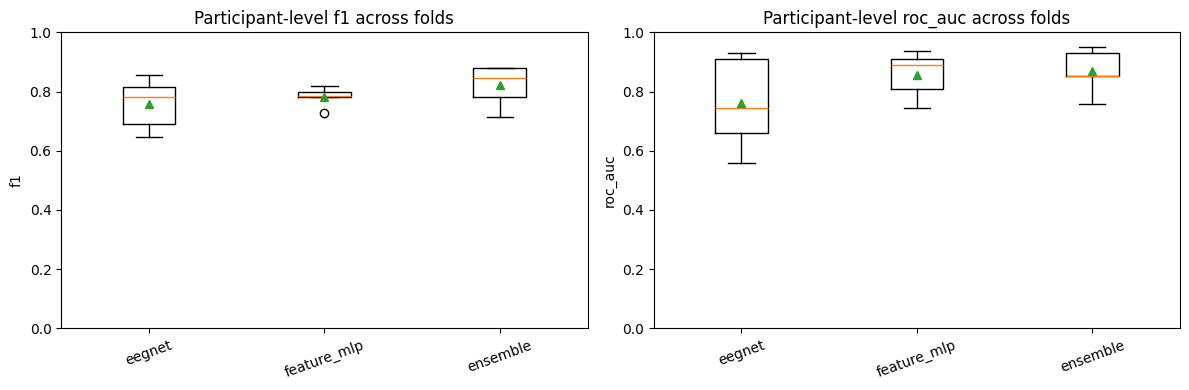

In [ ]:
# Comparison of fold F1 and ROC-AUC
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
models = ["eegnet", "feature_mlp", "ensemble"]
for axis, metric in zip(axes, ["f1", "roc_auc"]):
    data_to_plot = [fold_metrics.loc[fold_metrics["model"] == model, metric] for model in models]
    axis.boxplot(data_to_plot, labels=models, showmeans=True)
    axis.set_title(f"Participant-level {metric} across folds")
    axis.set_ylabel(metric)
    axis.set_ylim(0, 1)
    axis.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cross_validation_model_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

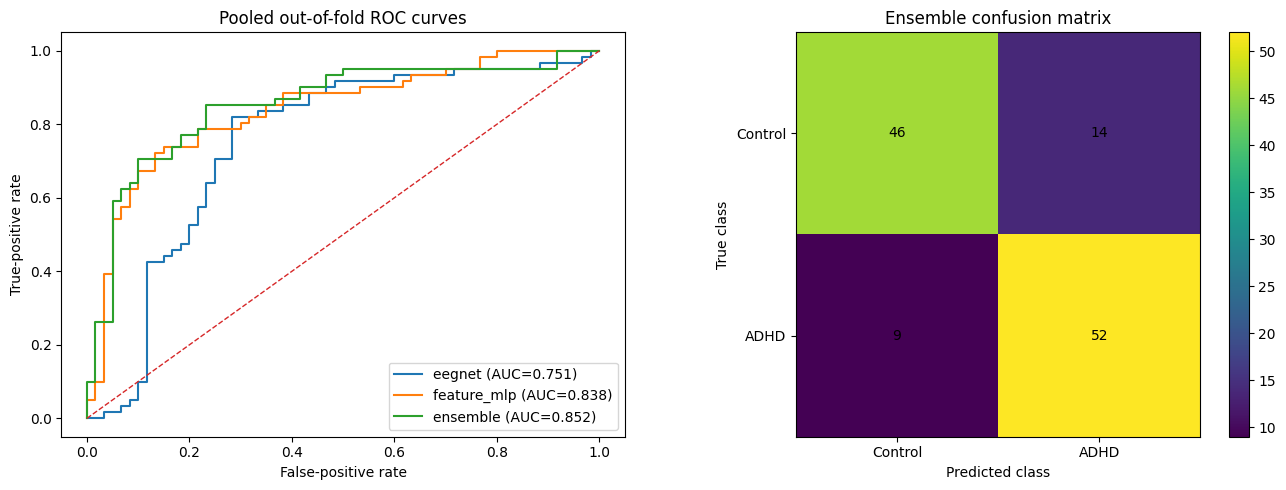

In [ ]:
# Pooled out-of-fold ROC curves and confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
y_true = oof_participant_predictions["label"].to_numpy()

for model_name in ["eegnet", "feature_mlp", "ensemble"]:
    probability = oof_participant_predictions[f"{model_name}_probability"].to_numpy()
    fpr, tpr, _ = roc_curve(y_true, probability)
    auc = roc_auc_score(y_true, probability)
    axes[0].plot(fpr, tpr, label=f"{model_name} (AUC={auc:.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", linewidth=1)
axes[0].set_xlabel("False-positive rate")
axes[0].set_ylabel("True-positive rate")
axes[0].set_title("Pooled out-of-fold ROC curves")
axes[0].legend()

ensemble_prediction = (oof_participant_predictions["ensemble_probability"] >= 0.5).astype(int)
cm = confusion_matrix(y_true, ensemble_prediction)
image = axes[1].imshow(cm)
axes[1].set_xticks([0, 1], ["Control", "ADHD"])
axes[1].set_yticks([0, 1], ["Control", "ADHD"])
axes[1].set_xlabel("Predicted class")
axes[1].set_ylabel("True class")
axes[1].set_title("Ensemble confusion matrix")
for row in range(2):
    for column in range(2):
        axes[1].text(column, row, cm[row, column], ha="center", va="center")
plt.colorbar(image, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "oof_roc_and_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

## 8. Temporal analysis across the attention task

Windows remain independent model inputs, but each model receives normalized position. The plots below also summarize out-of-fold probability over the course of the recording. They can reveal whether the model becomes more or less confident from early to late task periods.

,model,Class,task_period,mean,std,count
0,eegnet,ADHD,0–20%,0.706350,0.269704,843
1,eegnet,ADHD,20–40%,0.717343,0.269200,801
2,eegnet,ADHD,40–60%,0.725463,0.264284,796
3,eegnet,ADHD,60–80%,0.724640,0.263655,810
4,eegnet,ADHD,80–100%,0.728072,0.265370,791
5,eegnet,Control,0–20%,0.383645,0.354935,741
6,eegnet,Control,20–40%,0.382881,0.352872,714
7,eegnet,Control,40–60%,0.386522,0.356847,710
8,eegnet,Control,60–80%,0.391766,0.359942,713
9,eegnet,Control,80–100%,0.388685,0.354002,706


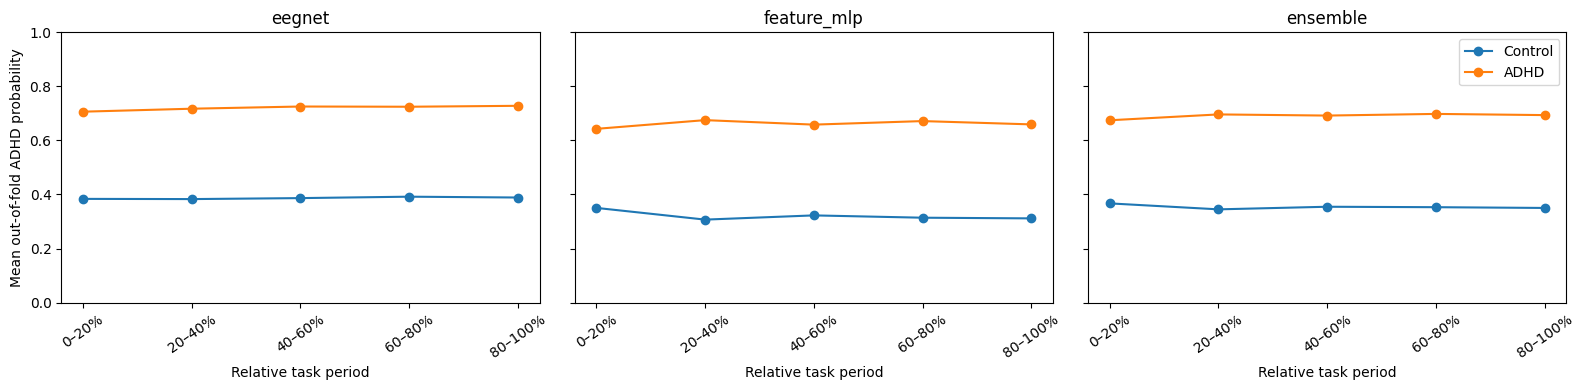

In [ ]:
# Add five relative-position bins and summarize out-of-fold window probabilities.
position_bins = np.linspace(0, 1, 6)
position_labels = ["0–20%", "20–40%", "40–60%", "60–80%", "80–100%"]
oof_window_predictions["task_period"] = pd.cut(
    oof_window_predictions["relative_position"],
    bins=position_bins,
    labels=position_labels,
    include_lowest=True,
)

temporal_summary_rows = []
for model_name in ["eegnet", "feature_mlp", "ensemble"]:
    grouped = (
        oof_window_predictions
        .groupby(["Class", "task_period"], observed=True)[f"{model_name}_window_probability"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    grouped.insert(0, "model", model_name)
    temporal_summary_rows.append(grouped)
temporal_summary = pd.concat(temporal_summary_rows, ignore_index=True)
temporal_summary.to_csv(OUTPUT_DIR / "temporal_probability_summary.csv", index=False)
display(temporal_summary.head(10))

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for axis, model_name in zip(axes, ["eegnet", "feature_mlp", "ensemble"]):
    subset = temporal_summary[temporal_summary["model"] == model_name]
    for class_name in ["Control", "ADHD"]:
        class_subset = subset[subset["Class"] == class_name]
        axis.plot(class_subset["task_period"].astype(str), class_subset["mean"], marker="o", label=class_name)
    axis.set_title(model_name)
    axis.set_xlabel("Relative task period")
    axis.tick_params(axis="x", rotation=35)
    axis.set_ylim(0, 1)
axes[0].set_ylabel("Mean out-of-fold ADHD probability")
axes[-1].legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "temporal_probability_trajectory.png", dpi=160, bbox_inches="tight")
plt.show()

## 9. Optional final models trained on all participants

These models are useful for later inference, but they do not have an independent performance estimate. Their epoch counts are the medians selected across the cross-validation folds.

In [ ]:
if TRAIN_FINAL_MODELS:
    all_indices = np.arange(len(window_metadata))
    final_eeg_epochs = max(1, int(round(epoch_selection["eegnet_epochs"].median())))
    final_mlp_epochs = max(1, int(round(epoch_selection["mlp_epochs"].median())))
    print("Final epochs:", {"EEGNet": final_eeg_epochs, "MLP": final_mlp_epochs})

    final_channel_mean, final_channel_std = compute_channel_stats(raw_windows, all_indices)
    final_raw_loader = make_loader(RawWindowDataset(
        raw_windows, window_metadata, all_indices,
        final_channel_mean, final_channel_std,
        augment=USE_RAW_AUGMENTATION,
    ), shuffle=True)

    final_scaler = StandardScaler()
    final_scaled_features = final_scaler.fit_transform(feature_matrix).astype(np.float32)
    final_feature_loader = make_loader(
        FeatureDataset(final_scaled_features, window_metadata, all_indices), shuffle=True
    )

    final_eegnet, _ = train_fixed_epochs(
        EEGNet(n_channels=len(EEG_CHANNELS)), final_raw_loader,
        final_eeg_epochs, seed=SEED + 9000
    )
    final_mlp, _ = train_fixed_epochs(
        FeatureMLP(len(FEATURE_NAMES)), final_feature_loader,
        final_mlp_epochs, seed=SEED + 9001
    )

    torch.save(final_eegnet.state_dict(), OUTPUT_DIR / "final_eegnet_all_participants.pt")
    torch.save(final_mlp.state_dict(), OUTPUT_DIR / "final_feature_mlp_all_participants.pt")
    if joblib is not None:
        joblib.dump(final_scaler, OUTPUT_DIR / "final_feature_scaler.joblib")
    else:
        np.savez(OUTPUT_DIR / "final_feature_scaler.npz", mean=final_scaler.mean_, scale=final_scaler.scale_)
    np.savez(
        OUTPUT_DIR / "final_raw_channel_scaler.npz",
        channel_mean=final_channel_mean,
        channel_std=final_channel_std,
    )
    print("Saved final models trained on all participants.")
else:
    print("TRAIN_FINAL_MODELS is False; final all-participant models were not trained.")

Final epochs: {'EEGNet': 5, 'MLP': 1}
Saved final models trained on all participants.


## 10. Automatic report-ready summary

Use participant-level metrics as the main result. Window-level probabilities are correlated within participants and should not be counted as independent clinical cases.

In [ ]:
ensemble_row = pooled_metrics.loc[pooled_metrics["model"] == "ensemble"].iloc[0]
ensemble_cv = fold_metrics[fold_metrics["model"] == "ensemble"]

summary_text = f"""
The fixed EEGNet–feature-MLP ensemble achieved pooled out-of-fold participant-level
accuracy of {ensemble_row['accuracy']:.3f}, F1 of {ensemble_row['f1']:.3f}, and ROC-AUC
of {ensemble_row['roc_auc']:.3f}. Across {N_SPLITS} participant-stratified folds, its mean
F1 was {ensemble_cv['f1'].mean():.3f} ± {ensemble_cv['f1'].std():.3f}, and its mean
ROC-AUC was {ensemble_cv['roc_auc'].mean():.3f} ± {ensemble_cv['roc_auc'].std():.3f}.
All windows from a participant remained in one fold. These findings are exploratory and
require external validation before any clinical interpretation.
""".strip()

print(summary_text)
with open(OUTPUT_DIR / "report_ready_summary.txt", "w") as file:
    file.write(summary_text + "\n")

The fixed EEGNet–feature-MLP ensemble achieved pooled out-of-fold participant-level
accuracy of 0.810, F1 of 0.819, and ROC-AUC
of 0.852. Across 5 participant-stratified folds, its mean
F1 was 0.821 ± 0.072, and its mean
ROC-AUC was 0.869 ± 0.077.
All windows from a participant remained in one fold. These findings are exploratory and
require external validation before any clinical interpretation.


In [ ]:
# Save configuration and create a ZIP archive.
configuration = {
    "seed": SEED,
    "sampling_rate_hz": SAMPLING_RATE_HZ,
    "window_size": WINDOW_SIZE,
    "window_stride": WINDOW_STRIDE,
    "max_windows_per_subject": MAX_WINDOWS_PER_SUBJECT,
    "frequency_features": USE_FREQUENCY_FEATURES,
    "n_splits": N_SPLITS,
    "batch_size": BATCH_SIZE,
    "eegnet_max_epochs": EEGNET_MAX_EPOCHS,
    "mlp_max_epochs": MLP_MAX_EPOCHS,
    "ensemble_eegnet_weight": ENSEMBLE_EEGNET_WEIGHT,
    "device": str(DEVICE),
    "number_of_participants": int(participant_labels["ID"].nunique()),
    "number_of_windows": int(len(window_metadata)),
    "number_of_features": int(len(FEATURE_NAMES)),
}
with open(OUTPUT_DIR / "run_configuration.json", "w") as file:
    json.dump(configuration, file, indent=2)

zip_base = OUTPUT_DIR.parent / f"{OUTPUT_DIR.name}"
zip_path = Path(shutil.make_archive(str(zip_base), "zip", root_dir=OUTPUT_DIR))

print("\nSaved output files:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(f"- {path.name} ({path.stat().st_size / 1024**2:.2f} MB)")
print("\nZIP archive:", zip_path)

if DOWNLOAD_ZIP_AT_END:
    try:
        from google.colab import files
        files.download(str(zip_path))
    except ImportError:
        print("Automatic download is available only in Google Colab.")
else:
    print("Set DOWNLOAD_ZIP_AT_END = True and rerun this cell to download the ZIP automatically.")


Saved output files:
- cross_validation_model_comparison.png (0.04 MB)
- cv_summary.csv (0.00 MB)
- dataset_overview.png (0.04 MB)
- example_raw_window.png (0.30 MB)
- feature_names.json (0.00 MB)
- final_eegnet_all_participants.pt (0.01 MB)
- final_feature_mlp_all_participants.pt (0.12 MB)
- final_feature_scaler.joblib (0.01 MB)
- final_raw_channel_scaler.npz (0.00 MB)
- fold_1_eegnet.pt (0.01 MB)
- fold_1_feature_mlp.pt (0.12 MB)
- fold_1_preprocessing.npz (0.00 MB)
- fold_2_eegnet.pt (0.01 MB)
- fold_2_feature_mlp.pt (0.12 MB)
- fold_2_preprocessing.npz (0.00 MB)
- fold_3_eegnet.pt (0.01 MB)
- fold_3_feature_mlp.pt (0.12 MB)
- fold_3_preprocessing.npz (0.00 MB)
- fold_4_eegnet.pt (0.01 MB)
- fold_4_feature_mlp.pt (0.12 MB)
- fold_4_preprocessing.npz (0.00 MB)
- fold_5_eegnet.pt (0.01 MB)
- fold_5_feature_mlp.pt (0.12 MB)
- fold_5_preprocessing.npz (0.00 MB)
- fold_metrics.csv (0.00 MB)
- oof_participant_predictions.csv (0.01 MB)
- oof_roc_and_confusion_matrix.png (0.09 MB)
- oof_win

## Methodological limitations to discuss

- The dataset contains only about 121 participants, so fold estimates can still vary.
- Windows from one participant are correlated; participant-level results are primary.
- The 128 Hz sampling rate and chronological row order should be verified from the source.
- Window labels inherit the participant diagnosis, even though not every short EEG segment must contain diagnostic information.
- The fixed ensemble is not guaranteed to outperform both component models.
- Medication status, task behavior, movement artifacts, age, and other confounds may contribute to group differences.
- Cross-validation estimates internal generalization within this dataset, not external clinical validity.